In [6]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader
from torchvision import transforms, datasets

In [7]:
LEARNING_RATE = 0.001
TRAIN_PATH = '../flower_dataset/train'
VAL_PATH = '../flower_dataset/valid'
TEST_PATH = '../flower_dataset/test'
BATCH_SIZE = 64
HIDDEN_SIZES = [512, 256, 128]
EPOCH = 10

In [8]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

data_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean = [0.5, 0.5, 0.5],
        std = [0.5, 0.5, 0.5]
    )
])

train_dataset = datasets.ImageFolder(root=TRAIN_PATH, transform=data_transform)
val_dataset = datasets.ImageFolder(root=VAL_PATH, transform=data_transform)
test_dataset = datasets.ImageFolder(root=TEST_PATH, transform=data_transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)


In [9]:
class MLP(nn.Module):
    def __init__(self, hidden_sizes):
        super().__init__()

        layers = []
        layers.append(nn.Flatten())
        input_size = 224 * 224 * 3

        for hidden_size in hidden_sizes:
            layers.append(nn.Linear(input_size, hidden_size))
            layers.append(nn.ReLU())
            input_size = hidden_size

        layers.append(nn.Linear(input_size, 102))
        self.sequential = nn.Sequential(*layers)

    def forward(self, x):
        return self.sequential(x)

In [10]:
model = MLP(HIDDEN_SIZES)

model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)

train_loss_list, val_loss_list, train_acc_list, val_acc_list = [], [], [], []

for epoch in range(EPOCH):
    train_loss_sum = 0
    train_correct = 0
    train_total = 0

    model.train()
        
    for images, labels in train_loader:

        images, labels = images.to(device), labels.to(device)    

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)
        train_loss_sum += loss.item()

        loss.backward()
        optimizer.step()

        predictions = outputs.argmax(dim=1)
        train_correct += (predictions == labels).sum().item()
        train_total += labels.size(0)

    train_loss = train_loss_sum / len(train_loader)
    train_acc = train_correct / train_total

    train_loss_list.append(train_loss)
    train_acc_list.append(train_acc)

    model.eval()

    val_loss_sum = 0
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            val_loss_sum += loss.item()

            predictions = outputs.argmax(dim=1)
            val_correct += (predictions == labels).sum().item()
            val_total += labels.size(0)


    val_loss = val_loss_sum / len(val_loader)
    val_acc = val_correct / val_total

    val_loss_list.append(val_loss)
    val_acc_list.append(val_acc)

    print(f"Epoch {epoch}:Train Loss: {train_loss} | Val Loss: {val_loss}")
    

Epoch 0:Train Loss: 5.028642603067252 | Val Loss: 4.332539312541485
Epoch 1:Train Loss: 4.059334938342754 | Val Loss: 3.9437504708766937
Epoch 2:Train Loss: 3.5469464228703425 | Val Loss: 3.661726236343384
Epoch 3:Train Loss: 3.169504503103403 | Val Loss: 3.5546195060014725
Epoch 4:Train Loss: 2.9187167644500733 | Val Loss: 3.5606385096907616
Epoch 5:Train Loss: 2.57822362276224 | Val Loss: 3.6160203218460083
Epoch 6:Train Loss: 2.3186145305633543 | Val Loss: 3.617329277098179
Epoch 7:Train Loss: 2.023920779961806 | Val Loss: 3.7663724161684513
Epoch 8:Train Loss: 1.8050460393612202 | Val Loss: 4.010845273733139
Epoch 9:Train Loss: 1.6693819192739634 | Val Loss: 4.139322340488434


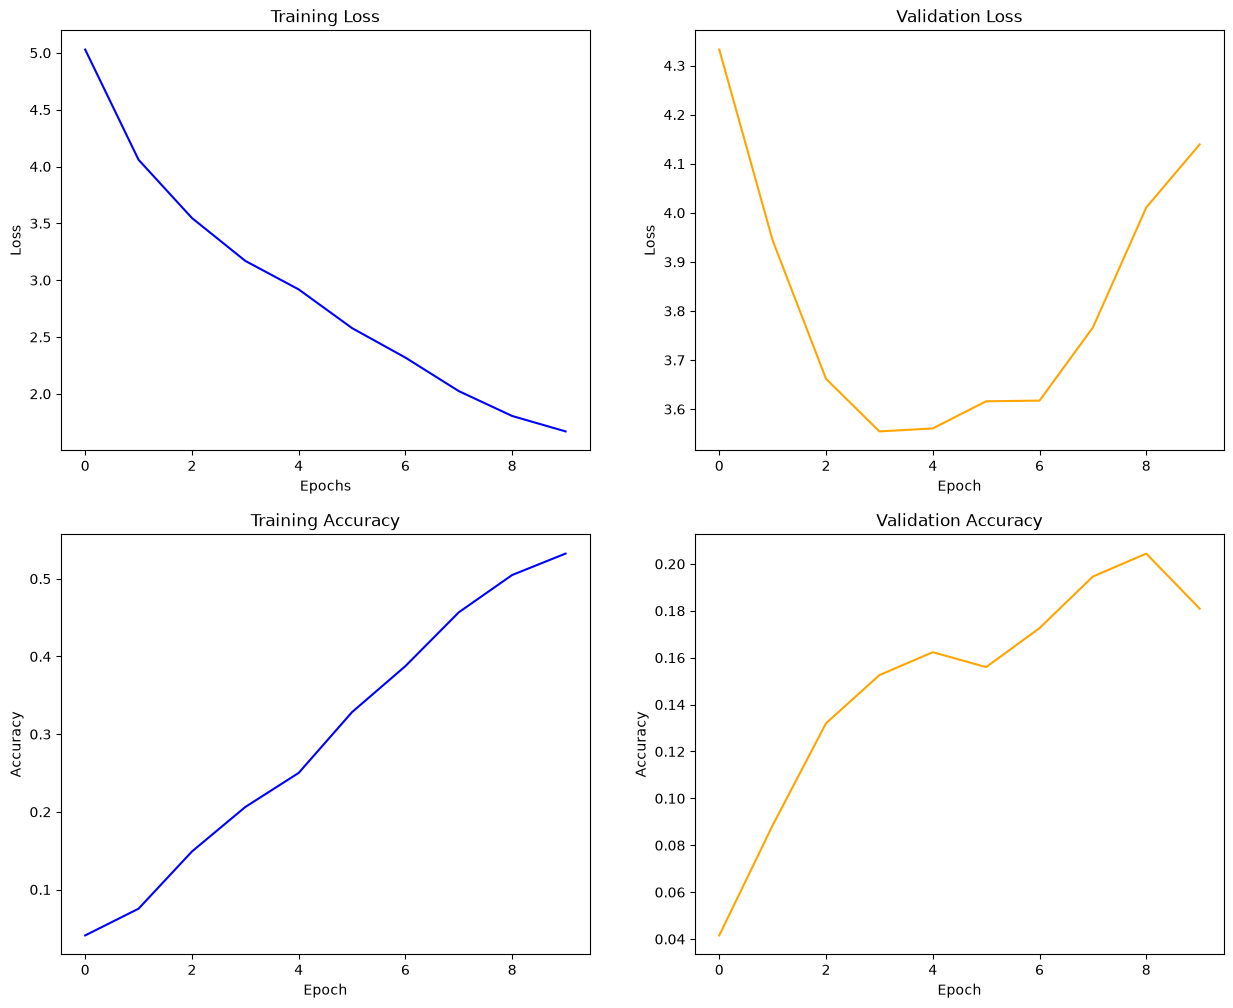

In [11]:
fig, (ax1, ax2) = plt.subplots(2, 2, figsize=(15, 12))

ax1[0].plot(train_loss_list, color='blue')
ax1[0].set_title('Training Loss')
ax1[0].set_xlabel('Epochs')
ax1[0].set_ylabel('Loss')

ax1[1].plot(val_loss_list, color='orange')
ax1[1].set_title('Validation Loss')
ax1[1].set_xlabel('Epoch')
ax1[1].set_ylabel('Loss')

ax2[0].plot(train_acc_list, color='blue')
ax2[0].set_title('Training Accuracy')
ax2[0].set_xlabel('Epoch')
ax2[0].set_ylabel('Accuracy')

ax2[1].plot(val_acc_list, color='orange')
ax2[1].set_title('Validation Accuracy')
ax2[1].set_xlabel('Epoch')
ax2[1].set_ylabel('Accuracy')


plt.show()

In [12]:
model.eval()

correct = 0
samples = 0

preds = []
true = []


with torch.no_grad():
    for images, labels in test_loader:

        images, labels = images.to(device), labels.to(device)

        outputs = model(images)
        predicted = torch.argmax(outputs, dim=1)
        correct += (predicted == labels).sum().item()
        samples += labels.size(0)

        preds.extend(predicted.tolist())
        true.extend(labels.tolist())

accuracy = correct/samples
print(accuracy)

0.20225269343780608
